### In this tutorial, we will use ```mne``` to load ```.cnt``` file

- author: Wei Liu
- Date: May 11, 2021
- [BCMI lab, Shanghai Jiao Tong University](http://bcmi.sjtu.edu.cn)

For more information about ```mne```, please go to website: [https://mne.tools/stable/index.html](https://mne.tools/stable/index.html)

In [9]:
import numpy as np
import mne

print(np.__version__)
print(mne.__version__)

2.4.4
1.12.1


In [ ]:
# use mne to load the file "1_1_20180804.cnt"
eeg_raw = mne.io.read_raw_cnt('../data/raw/1_1_20180804.cnt')
print(eeg_raw)
print('\n')
print(eeg_raw.info)

In [11]:
# check channel names
ch_names = eeg_raw.ch_names
print(ch_names)
print(len(ch_names))
print('\n')

# drop non-used channels
useless_ch = ['M1', 'M2', 'VEO', 'HEO']
eeg_raw.drop_channels(useless_ch)
new_ch = eeg_raw.ch_names
print(new_ch)
print(len(new_ch))
print('\n')

['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'M1', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'M2', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'OZ', 'O2', 'CB2', 'VEO', 'HEO']
66


['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'OZ', 'O2', 'CB2']
62




Using matplotlib as 2D backend.


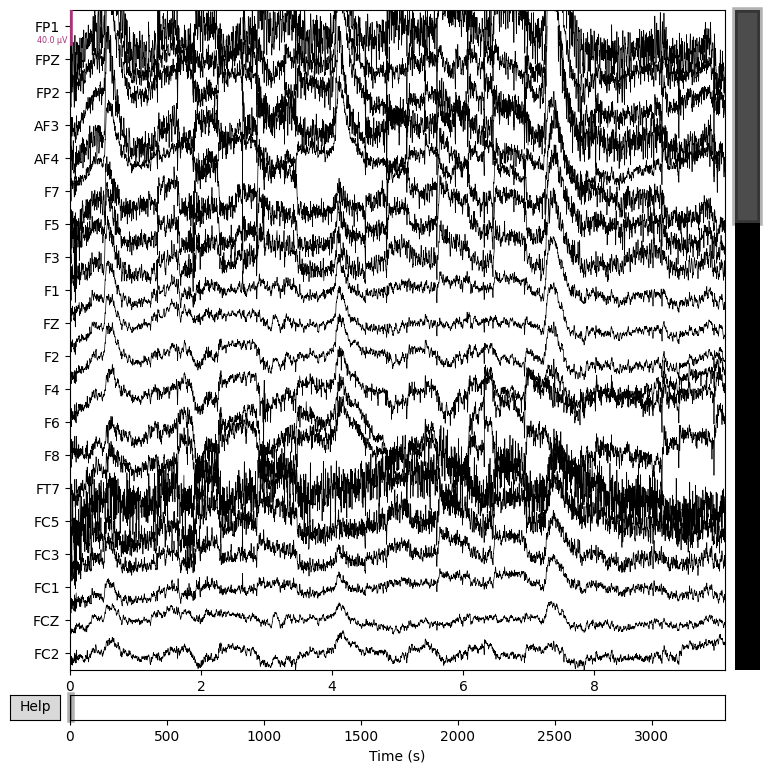

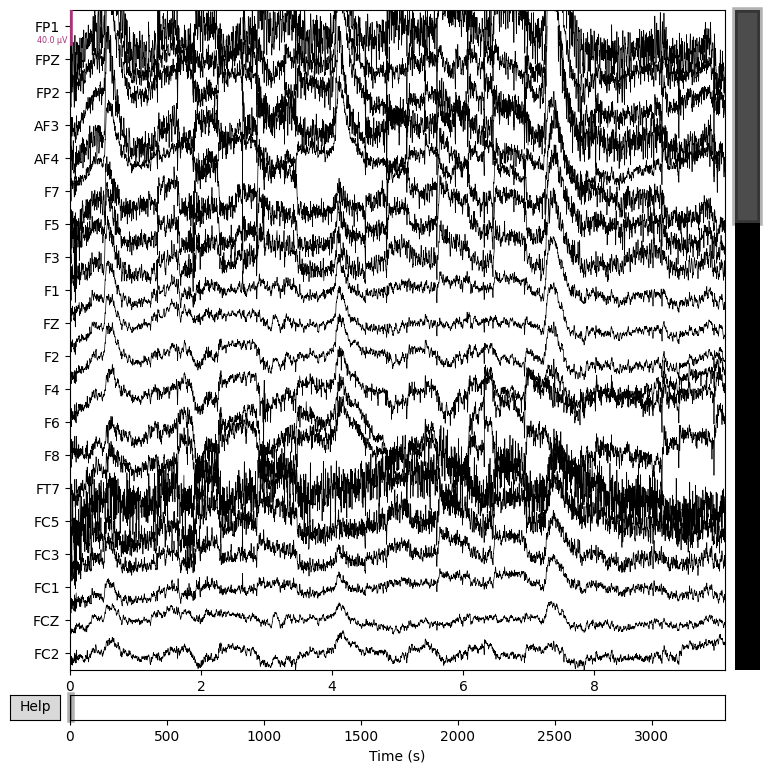

In [12]:
# see raw data wave
eeg_raw.plot()

In [13]:
# get the data matrix
data_matrix = eeg_raw.get_data()
print(data_matrix.shape)

(62, 3378360)


In [14]:
# with file "trial_start_end_timestamp.txt", you can split the data into different trials
start_second = [30, 353, 478, 674, 825, 908, 1200, 1346, 1451, 1711, 2055, 2307, 2457, 2726, 2888]
end_second = [321, 418, 643, 764, 877, 1147, 1284, 1418, 1679, 1996, 2275, 2425, 2664, 2857, 3066]

###########################################################
### Notice: we did not filt the orignal signal here #######
### you may need to filt the data before other process ####
### To filt the signal, please refer to MNE documents #####
###########################################################
start_second = [30, 353, 478, 674, 825, 908, 1200, 1346, 1451, 1711, 2055, 2307, 2457, 2726, 2888]
end_second = [321, 418, 643, 764, 877, 1147, 1284, 1418, 1679, 1996, 2275, 2425, 2664, 2857, 3066]
sample_freq = 1000

data_trial_1 = data_matrix[:, start_second[0]*1000 : end_second[0]*1000]
data_trial_5 = data_matrix[:, start_second[4]*1000 : end_second[4]*1000]
data_trial_15 = data_matrix[:, start_second[14]*1000 : end_second[14]*1000]

print(data_trial_1.shape)
print(data_trial_5.shape)
print(data_trial_15.shape)

(62, 291000)
(62, 52000)
(62, 178000)


With the extract clips, you can extract any features.